# 第二十五章：DDPM (Denoising Diffusion Probabilistic Models) — PyTorch 實作

本 notebook 實作 DDPM 擴散模型，展示前向擴散和反向去噪過程。

**論文**: Denoising Diffusion Probabilistic Models  
**作者**: Jonathan Ho, Ajay Jain, Pieter Abbeel  
**機構**: UC Berkeley  
**發表**: arXiv:2006.11239, June 2020 (NeurIPS 2020)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from tqdm import tqdm
import math

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 檢查 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用裝置: {device}')

使用裝置: cuda


## 25.1 噪聲排程 (Noise Schedule)

DDPM 的核心是定義一個噪聲排程 $\beta_t$，控制前向過程中添加噪聲的程度。

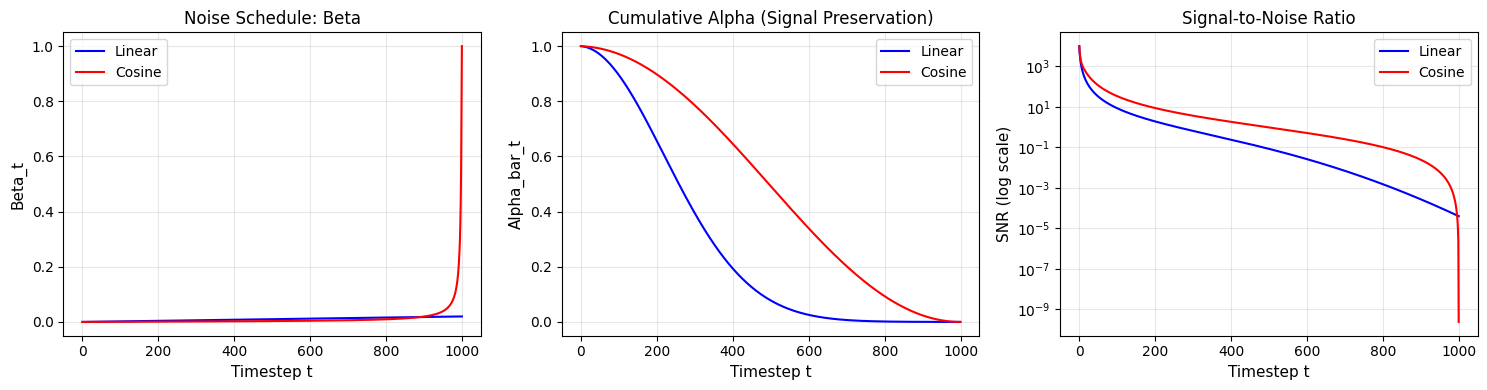

線性排程: beta 從 0.000100 到 0.020000
餘弦排程: beta 從 0.000100 到 0.999900


In [2]:
def linear_beta_schedule(timesteps, beta_start=0.0001, beta_end=0.02):
    """
    線性 beta 排程（DDPM 原論文使用）
    """
    return torch.linspace(beta_start, beta_end, timesteps)

def cosine_beta_schedule(timesteps, s=0.008):
    """
    餘弦 beta 排程（Improved DDPM 提出）
    在末端更平滑，生成品質通常更好
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

# 比較兩種排程
T = 1000
linear_betas = linear_beta_schedule(T)
cosine_betas = cosine_beta_schedule(T)

# 計算累積 alpha
linear_alphas = 1 - linear_betas
linear_alphas_cumprod = torch.cumprod(linear_alphas, dim=0)

cosine_alphas = 1 - cosine_betas
cosine_alphas_cumprod = torch.cumprod(cosine_alphas, dim=0)

# 視覺化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Beta 值
axes[0].plot(linear_betas, label='Linear', color='blue')
axes[0].plot(cosine_betas, label='Cosine', color='red')
axes[0].set_xlabel('Timestep t', fontsize=11)
axes[0].set_ylabel('Beta_t', fontsize=11)
axes[0].set_title('Noise Schedule: Beta', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 累積 alpha
axes[1].plot(linear_alphas_cumprod, label='Linear', color='blue')
axes[1].plot(cosine_alphas_cumprod, label='Cosine', color='red')
axes[1].set_xlabel('Timestep t', fontsize=11)
axes[1].set_ylabel('Alpha_bar_t', fontsize=11)
axes[1].set_title('Cumulative Alpha (Signal Preservation)', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 信噪比 (SNR)
linear_snr = linear_alphas_cumprod / (1 - linear_alphas_cumprod)
cosine_snr = cosine_alphas_cumprod / (1 - cosine_alphas_cumprod)

axes[2].semilogy(linear_snr, label='Linear', color='blue')
axes[2].semilogy(cosine_snr, label='Cosine', color='red')
axes[2].set_xlabel('Timestep t', fontsize=11)
axes[2].set_ylabel('SNR (log scale)', fontsize=11)
axes[2].set_title('Signal-to-Noise Ratio', fontsize=12)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('noise_schedules.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"線性排程: beta 從 {linear_betas[0]:.6f} 到 {linear_betas[-1]:.6f}")
print(f"餘弦排程: beta 從 {cosine_betas[0]:.6f} 到 {cosine_betas[-1]:.6f}")

## 25.2 前向擴散過程視覺化

前向過程逐步向圖像添加高斯噪聲，直到圖像變成純噪聲。

In [3]:
class DiffusionUtils:
    """
    擴散模型的工具類，包含前向和反向過程的核心計算
    """
    def __init__(self, timesteps=1000, beta_schedule='linear'):
        self.timesteps = timesteps
        
        # 設定 beta 排程
        if beta_schedule == 'linear':
            self.betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            self.betas = cosine_beta_schedule(timesteps)
        else:
            raise ValueError(f"Unknown beta schedule: {beta_schedule}")
        
        # 預計算所有需要的係數
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # 前向過程係數
        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - self.alphas_cumprod)
        
        # 反向過程係數
        self.sqrt_recip_alphas = torch.sqrt(1.0 / self.alphas)
        self.posterior_variance = self.betas * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)
    
    def extract(self, a, t, x_shape):
        """從係數向量中提取對應時間步的值，並調整形狀以便廣播"""
        batch_size = t.shape[0]
        out = a.gather(-1, t.cpu())
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)
    
    def q_sample(self, x_0, t, noise=None):
        """
        前向過程：從 x_0 直接採樣 x_t
        
        x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
        """
        if noise is None:
            noise = torch.randn_like(x_0)
        
        sqrt_alphas_cumprod_t = self.extract(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alphas_cumprod_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise

# 初始化
diffusion = DiffusionUtils(timesteps=1000, beta_schedule='linear')

# 載入一張測試圖片
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 將像素值映射到 [-1, 1]
])

mnist = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_img = mnist[0][0].unsqueeze(0)  # (1, 1, 28, 28)

print(f"測試圖片形狀: {test_img.shape}")
print(f"像素值範圍: [{test_img.min():.2f}, {test_img.max():.2f}]")

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 343kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.84MB/s]

測試圖片形狀: torch.Size([1, 1, 28, 28])
像素值範圍: [-1.00, 1.00]


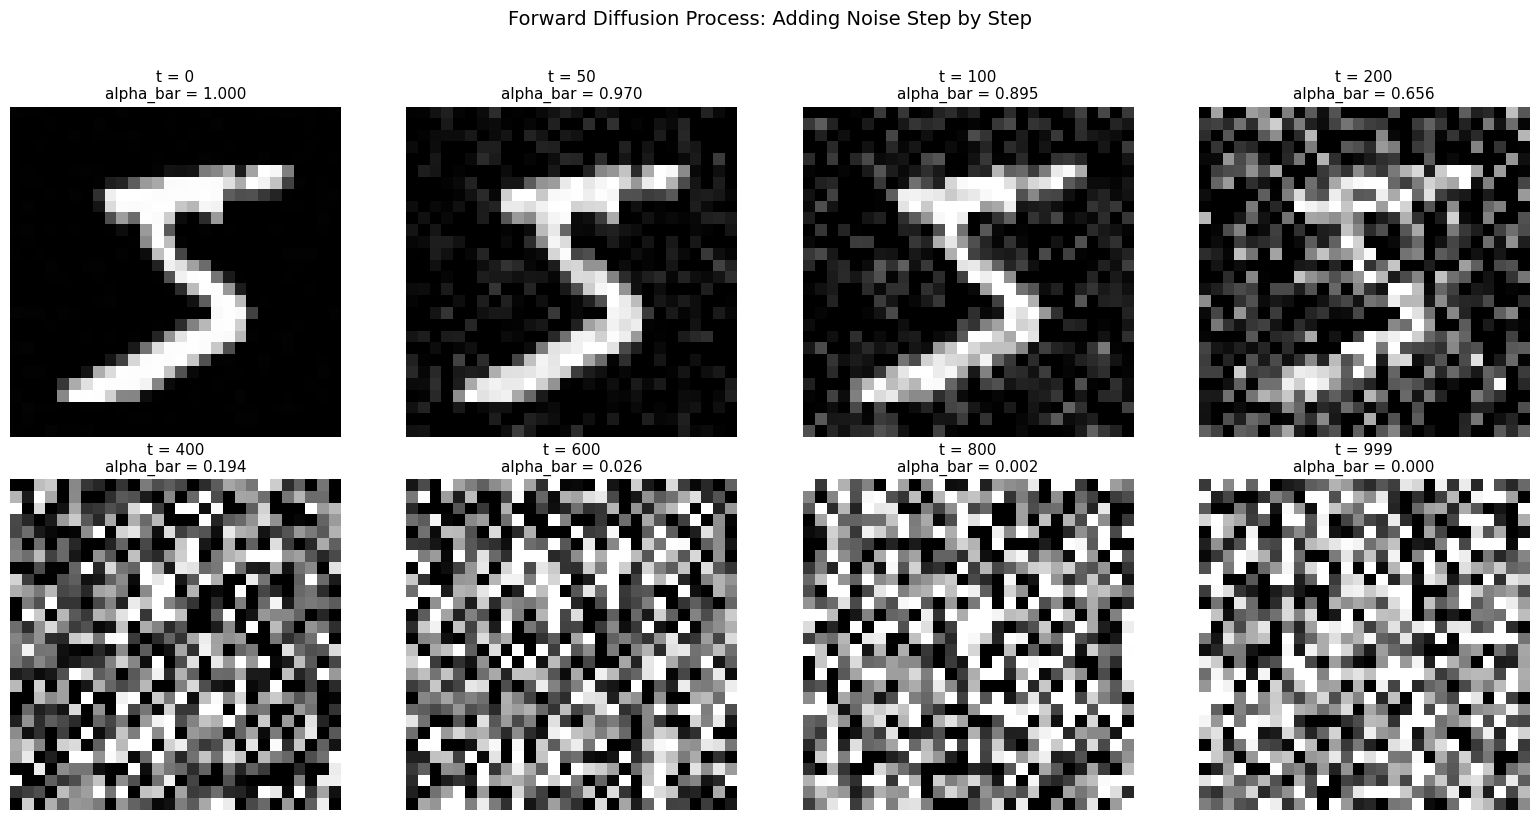

In [4]:
# 視覺化前向擴散過程
timesteps_to_show = [0, 50, 100, 200, 400, 600, 800, 999]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, t in enumerate(timesteps_to_show):
    t_tensor = torch.tensor([t])
    noisy_img = diffusion.q_sample(test_img, t_tensor)
    
    # 將圖片轉回 [0, 1] 範圍以便顯示
    img_display = (noisy_img[0, 0].numpy() + 1) / 2
    img_display = np.clip(img_display, 0, 1)
    
    axes[idx].imshow(img_display, cmap='gray')
    axes[idx].set_title(f't = {t}\nalpha_bar = {diffusion.alphas_cumprod[t]:.3f}', fontsize=11)
    axes[idx].axis('off')

plt.suptitle('Forward Diffusion Process: Adding Noise Step by Step', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('forward_diffusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 25.3 U-Net 去噪網路

DDPM 使用 U-Net 架構作為去噪網路，預測添加到圖像中的噪聲。

In [5]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    時間步的正弦位置編碼
    類似於 Transformer 中的位置編碼
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """
    基本卷積區塊：Conv -> GroupNorm -> SiLU
    """
    def __init__(self, in_ch, out_ch, groups=8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.norm = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()
    
    def forward(self, x):
        return self.act(self.norm(self.conv(x)))

class ResBlock(nn.Module):
    """
    殘差區塊，包含時間嵌入的注入
    """
    def __init__(self, in_ch, out_ch, time_emb_dim, groups=8):
        super().__init__()
        self.block1 = Block(in_ch, out_ch, groups)
        self.block2 = Block(out_ch, out_ch, groups)
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        self.res_conv = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    
    def forward(self, x, t):
        h = self.block1(x)
        # 加入時間嵌入
        h = h + self.time_mlp(t)[:, :, None, None]
        h = self.block2(h)
        return h + self.res_conv(x)

class Attention(nn.Module):
    """
    簡化的自注意力層
    """
    def __init__(self, channels, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
    
    def forward(self, x):
        B, C, H, W = x.shape
        x_norm = self.norm(x)
        qkv = self.qkv(x_norm).reshape(B, 3, self.num_heads, C // self.num_heads, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]
        
        # Scaled dot-product attention
        scale = (C // self.num_heads) ** -0.5
        attn = torch.einsum('bhci,bhcj->bhij', q, k) * scale
        attn = attn.softmax(dim=-1)
        out = torch.einsum('bhij,bhcj->bhci', attn, v)
        out = out.reshape(B, C, H, W)
        return x + self.proj(out)

class UNet(nn.Module):
    """
    簡化版 U-Net 用於 DDPM
    """
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, time_emb_dim=256):
        super().__init__()
        
        # 時間嵌入
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        
        # Encoder (下採樣路徑)
        self.conv_in = nn.Conv2d(in_channels, base_channels, 3, padding=1)
        
        self.down1 = ResBlock(base_channels, base_channels, time_emb_dim)
        self.down2 = ResBlock(base_channels, base_channels * 2, time_emb_dim)
        self.attn1 = Attention(base_channels * 2)
        self.down3 = ResBlock(base_channels * 2, base_channels * 4, time_emb_dim)
        
        self.pool = nn.MaxPool2d(2)
        
        # Bottleneck
        self.mid1 = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        self.mid_attn = Attention(base_channels * 4)
        self.mid2 = ResBlock(base_channels * 4, base_channels * 4, time_emb_dim)
        
        # Decoder (上採樣路徑)
        self.up1 = ResBlock(base_channels * 8, base_channels * 2, time_emb_dim)
        self.attn2 = Attention(base_channels * 2)
        self.up2 = ResBlock(base_channels * 4, base_channels, time_emb_dim)
        self.up3 = ResBlock(base_channels * 2, base_channels, time_emb_dim)
        
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')
        
        # 輸出層
        self.conv_out = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, out_channels, 3, padding=1)
        )
    
    def forward(self, x, t):
        # 時間嵌入
        t_emb = self.time_mlp(t)
        
        # Encoder
        x1 = self.conv_in(x)  # (B, 64, H, W)
        x1 = self.down1(x1, t_emb)
        
        x2 = self.pool(x1)
        x2 = self.down2(x2, t_emb)  # (B, 128, H/2, W/2)
        x2 = self.attn1(x2)
        
        x3 = self.pool(x2)
        x3 = self.down3(x3, t_emb)  # (B, 256, H/4, W/4)
        
        # Bottleneck
        x_mid = self.pool(x3)
        x_mid = self.mid1(x_mid, t_emb)  # (B, 256, H/8, W/8)
        x_mid = self.mid_attn(x_mid)
        x_mid = self.mid2(x_mid, t_emb)
        
        # Decoder
        x = self.upsample(x_mid)
        x = torch.cat([x, x3], dim=1)  # Skip connection
        x = self.up1(x, t_emb)
        x = self.attn2(x)
        
        x = self.upsample(x)
        x = torch.cat([x, x2], dim=1)
        x = self.up2(x, t_emb)
        
        x = self.upsample(x)
        x = torch.cat([x, x1], dim=1)
        x = self.up3(x, t_emb)
        
        return self.conv_out(x)

# 測試 U-Net
model = UNet(in_channels=1, out_channels=1, base_channels=64)
test_x = torch.randn(2, 1, 32, 32)  # 使用 32x32 以便 3 次下採樣
test_t = torch.tensor([100, 500])
output = model(test_x, test_t)

print(f"輸入形狀: {test_x.shape}")
print(f"輸出形狀: {output.shape}")
print(f"模型參數量: {sum(p.numel() for p in model.parameters()):,}")

輸入形狀: torch.Size([2, 1, 32, 32])
輸出形狀: torch.Size([2, 1, 32, 32])
模型參數量: 5,551,873


## 25.4 完整的 DDPM 模型

In [6]:
class DDPM(nn.Module):
    """
    完整的 DDPM 模型
    包含訓練和採樣的所有功能
    """
    def __init__(self, model, timesteps=1000, beta_schedule='linear'):
        super().__init__()
        self.model = model
        self.timesteps = timesteps
        
        # 初始化擴散係數
        if beta_schedule == 'linear':
            betas = linear_beta_schedule(timesteps)
        elif beta_schedule == 'cosine':
            betas = cosine_beta_schedule(timesteps)
        
        alphas = 1 - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        alphas_cumprod_prev = F.pad(alphas_cumprod[:-1], (1, 0), value=1.0)
        
        # 註冊為 buffer（不參與梯度計算，但會隨模型保存）
        self.register_buffer('betas', betas)
        self.register_buffer('alphas_cumprod', alphas_cumprod)
        self.register_buffer('alphas_cumprod_prev', alphas_cumprod_prev)
        self.register_buffer('sqrt_alphas_cumprod', torch.sqrt(alphas_cumprod))
        self.register_buffer('sqrt_one_minus_alphas_cumprod', torch.sqrt(1 - alphas_cumprod))
        self.register_buffer('sqrt_recip_alphas', torch.sqrt(1.0 / alphas))
        
        # 後驗方差
        posterior_variance = betas * (1 - alphas_cumprod_prev) / (1 - alphas_cumprod)
        self.register_buffer('posterior_variance', posterior_variance)
    
    def extract(self, a, t, x_shape):
        """從係數向量中提取對應時間步的值"""
        batch_size = t.shape[0]
        out = a.gather(-1, t)
        return out.reshape(batch_size, *((1,) * (len(x_shape) - 1)))
    
    def q_sample(self, x_0, t, noise=None):
        """
        前向過程：q(x_t | x_0)
        """
        if noise is None:
            noise = torch.randn_like(x_0)
        
        sqrt_alphas_cumprod_t = self.extract(self.sqrt_alphas_cumprod, t, x_0.shape)
        sqrt_one_minus_alphas_cumprod_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x_0.shape)
        
        return sqrt_alphas_cumprod_t * x_0 + sqrt_one_minus_alphas_cumprod_t * noise
    
    def compute_loss(self, x_0, t, noise=None):
        """
        計算訓練損失：L_simple = E[||epsilon - epsilon_theta(x_t, t)||^2]
        """
        if noise is None:
            noise = torch.randn_like(x_0)
        
        x_t = self.q_sample(x_0, t, noise)
        predicted_noise = self.model(x_t, t)
        
        loss = F.mse_loss(predicted_noise, noise)
        return loss
    
    @torch.no_grad()
    def p_sample(self, x_t, t, t_index):
        """
        反向過程的單步採樣：p(x_{t-1} | x_t)
        """
        betas_t = self.extract(self.betas, t, x_t.shape)
        sqrt_one_minus_alphas_cumprod_t = self.extract(self.sqrt_one_minus_alphas_cumprod, t, x_t.shape)
        sqrt_recip_alphas_t = self.extract(self.sqrt_recip_alphas, t, x_t.shape)
        
        # 預測噪聲
        predicted_noise = self.model(x_t, t)
        
        # 計算均值
        model_mean = sqrt_recip_alphas_t * (
            x_t - betas_t * predicted_noise / sqrt_one_minus_alphas_cumprod_t
        )
        
        if t_index == 0:
            return model_mean
        else:
            posterior_variance_t = self.extract(self.posterior_variance, t, x_t.shape)
            noise = torch.randn_like(x_t)
            return model_mean + torch.sqrt(posterior_variance_t) * noise
    
    @torch.no_grad()
    def sample(self, shape, return_all_steps=False):
        """
        從純噪聲生成圖像
        """
        device = next(self.model.parameters()).device
        batch_size = shape[0]
        
        # 從純噪聲開始
        x = torch.randn(shape, device=device)
        
        all_steps = [x.cpu()] if return_all_steps else None
        
        # 逐步去噪
        for i in reversed(range(self.timesteps)):
            t = torch.full((batch_size,), i, device=device, dtype=torch.long)
            x = self.p_sample(x, t, i)
            
            if return_all_steps and i % 100 == 0:
                all_steps.append(x.cpu())
        
        if return_all_steps:
            all_steps.append(x.cpu())
            return x, all_steps
        return x

# 創建 DDPM 模型
unet = UNet(in_channels=1, out_channels=1, base_channels=64).to(device)
ddpm = DDPM(unet, timesteps=1000, beta_schedule='linear').to(device)

print(f"DDPM 模型已創建，timesteps={ddpm.timesteps}")

DDPM 模型已創建，timesteps=1000


## 25.5 訓練 DDPM

In [7]:
# 準備資料
transform = transforms.Compose([
    transforms.Resize(32),  # 調整為 32x32
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 映射到 [-1, 1]
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)

print(f"訓練資料數量: {len(train_dataset)}")
print(f"每批次大小: 128")
print(f"每 epoch 批次數: {len(train_loader)}")

訓練資料數量: 60000
每批次大小: 128
每 epoch 批次數: 469


In [8]:
# 訓練函數
def train_ddpm(model, train_loader, epochs=10, lr=2e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    losses = []
    
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        
        for batch_idx, (x, _) in enumerate(pbar):
            x = x.to(device)
            batch_size = x.shape[0]
            
            # 隨機選擇時間步
            t = torch.randint(0, model.timesteps, (batch_size,), device=device).long()
            
            # 計算損失
            loss = model.compute_loss(x, t)
            
            # 反向傳播
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        avg_loss = epoch_loss / len(train_loader)
        losses.append(avg_loss)
        print(f'Epoch {epoch+1}: 平均損失 = {avg_loss:.4f}')
    
    return losses

# 訓練（減少 epoch 數以加快演示）
print("開始訓練 DDPM...")
losses = train_ddpm(ddpm, train_loader, epochs=5, lr=2e-4)

開始訓練 DDPM...


Epoch 1/5: 100%|██████████| 469/469 [00:58<00:00,  8.06it/s, loss=0.0213]


Epoch 1: 平均損失 = 0.0516


Epoch 2/5: 100%|██████████| 469/469 [00:57<00:00,  8.20it/s, loss=0.0167]


Epoch 2: 平均損失 = 0.0248


...

Epoch 3: 平均損失 = 0.0220


Epoch 4/5: 100%|██████████| 469/469 [00:58<00:00,  8.05it/s, loss=0.0194]


Epoch 4: 平均損失 = 0.0201


Epoch 5/5: 100%|██████████| 469/469 [00:58<00:00,  8.01it/s, loss=0.0118]

Epoch 5: 平均損失 = 0.0192


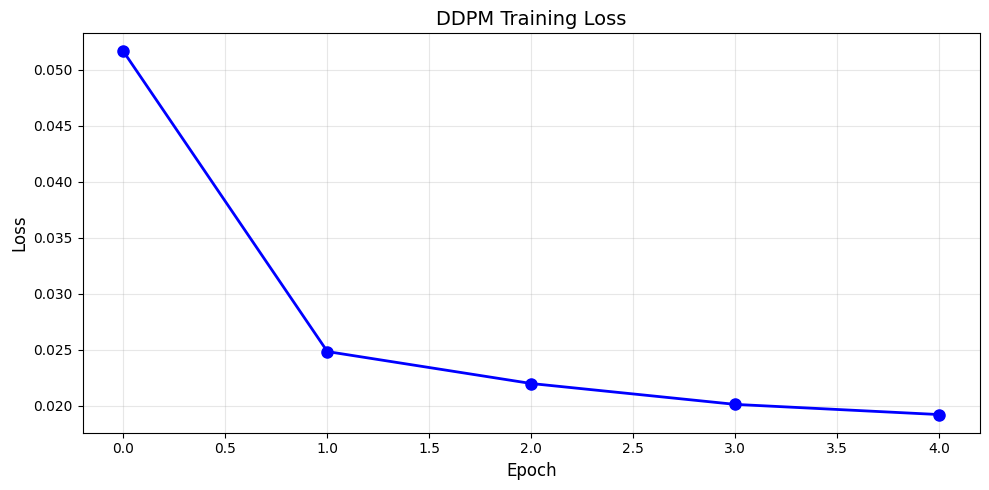

In [9]:
# 視覺化訓練損失
plt.figure(figsize=(10, 5))
plt.plot(losses, 'b-', linewidth=2, marker='o', markersize=8)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('DDPM Training Loss', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ddpm_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 25.6 採樣與生成

生成樣本中...（需要 1000 步迭代）


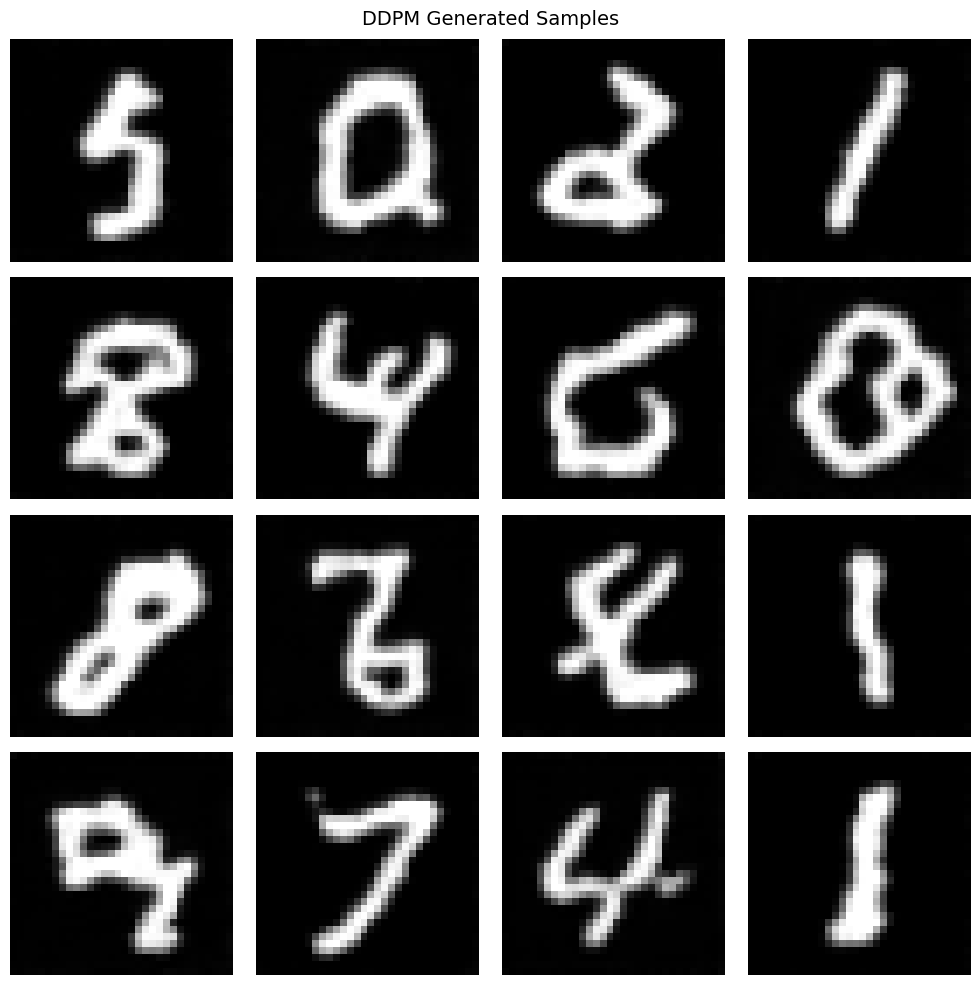

In [10]:
# 生成樣本
print("生成樣本中...（需要 1000 步迭代）")
ddpm.eval()

with torch.no_grad():
    samples, all_steps = ddpm.sample((16, 1, 32, 32), return_all_steps=True)

# 視覺化生成的樣本
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for idx, ax in enumerate(axes.flatten()):
    img = (samples[idx, 0].cpu().numpy() + 1) / 2
    img = np.clip(img, 0, 1)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.suptitle('DDPM Generated Samples', fontsize=14)
plt.tight_layout()
plt.savefig('ddpm_generated_samples.png', dpi=150, bbox_inches='tight')
plt.show()

視覺化去噪過程...


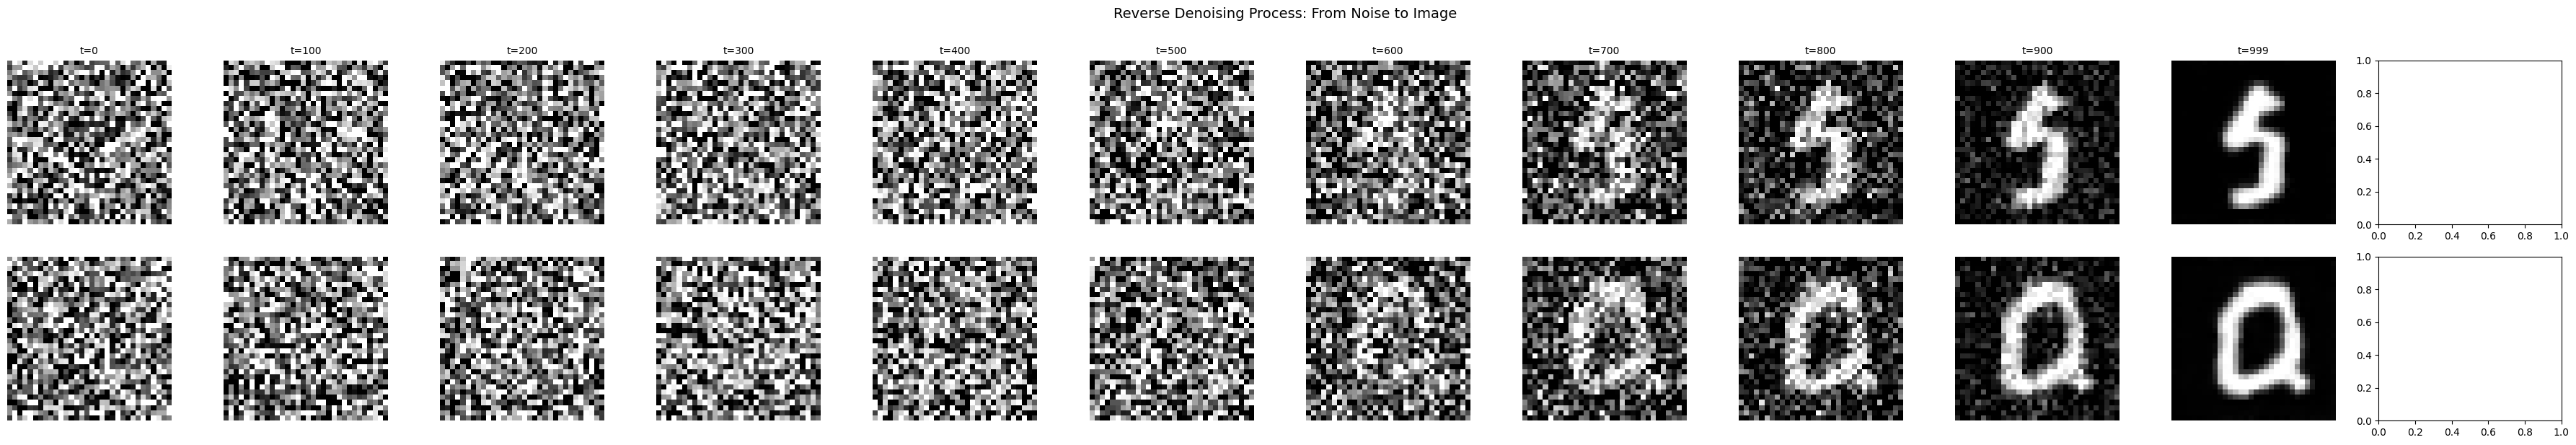

In [11]:
# 視覺化反向去噪過程
print("視覺化去噪過程...")

fig, axes = plt.subplots(2, len(all_steps), figsize=(3*len(all_steps), 6))

timesteps_shown = [999, 900, 800, 700, 600, 500, 400, 300, 200, 100, 0]
timesteps_shown = timesteps_shown[:len(all_steps)]

for idx, (step, t) in enumerate(zip(all_steps, reversed(timesteps_shown))):
    # 顯示第一個樣本
    img1 = (step[0, 0].numpy() + 1) / 2
    img1 = np.clip(img1, 0, 1)
    axes[0, idx].imshow(img1, cmap='gray')
    axes[0, idx].set_title(f't={t}', fontsize=10)
    axes[0, idx].axis('off')
    
    # 顯示第二個樣本
    img2 = (step[1, 0].numpy() + 1) / 2
    img2 = np.clip(img2, 0, 1)
    axes[1, idx].imshow(img2, cmap='gray')
    axes[1, idx].axis('off')

plt.suptitle('Reverse Denoising Process: From Noise to Image', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('ddpm_denoising_process.png', dpi=150, bbox_inches='tight')
plt.show()

## 25.7 擴散過程的數學視覺化

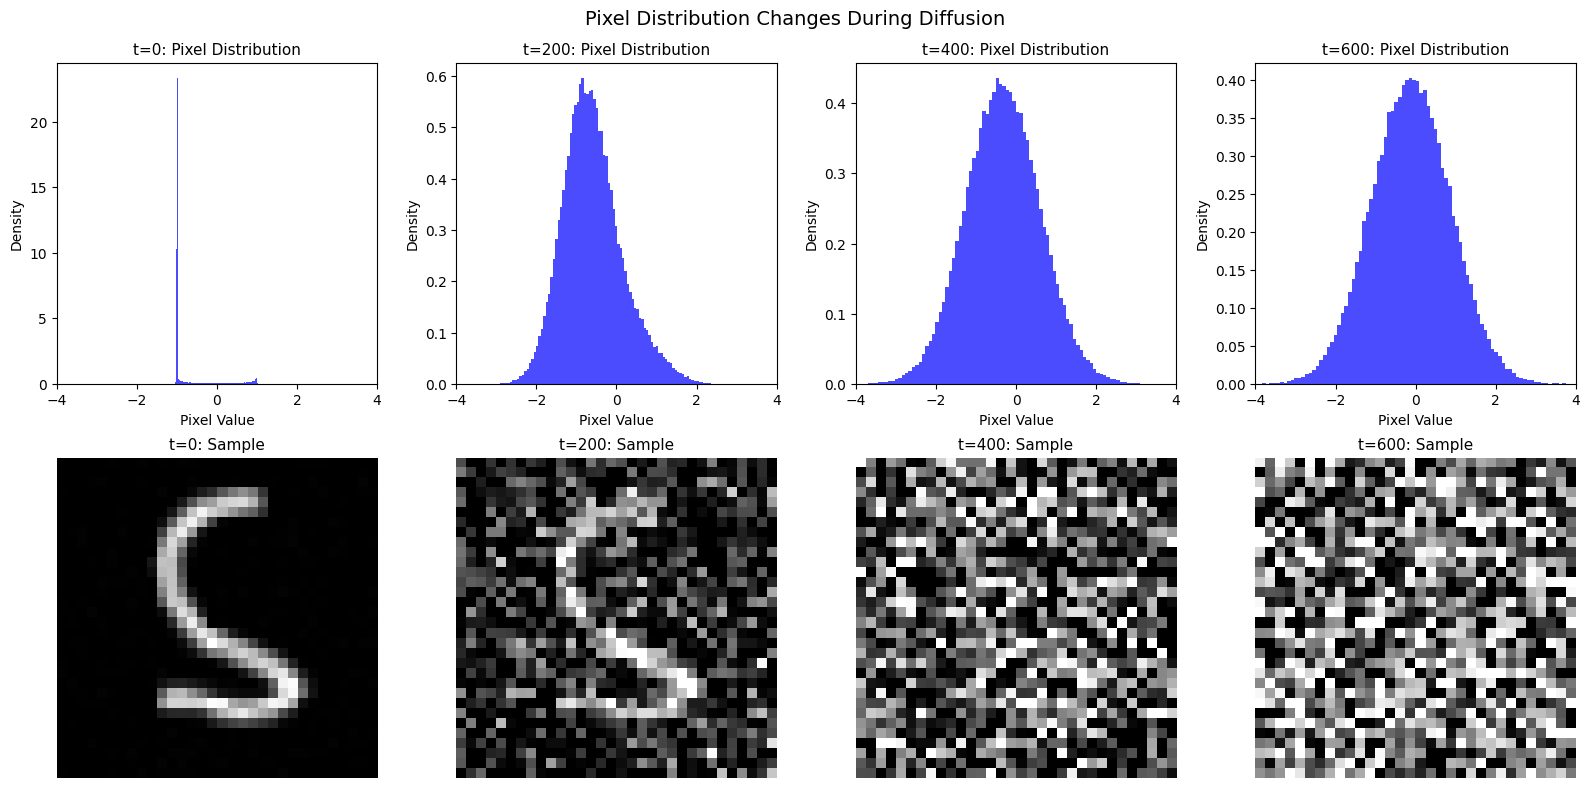

In [12]:
# 視覺化不同 t 下的噪聲分布
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

timesteps_to_show = [0, 200, 400, 600]

# 從資料集取一批圖片
sample_batch, _ = next(iter(train_loader))
sample_batch = sample_batch[:1000].to(device)  # 取 1000 張

for col, t in enumerate(timesteps_to_show):
    t_tensor = torch.full((sample_batch.shape[0],), t, device=device, dtype=torch.long)
    noisy_batch = ddpm.q_sample(sample_batch, t_tensor)
    
    # 像素值分布
    axes[0, col].hist(noisy_batch.cpu().flatten().numpy(), bins=100, density=True, alpha=0.7, color='blue')
    axes[0, col].set_title(f't={t}: Pixel Distribution', fontsize=11)
    axes[0, col].set_xlabel('Pixel Value', fontsize=10)
    axes[0, col].set_ylabel('Density', fontsize=10)
    axes[0, col].set_xlim(-4, 4)
    
    # 顯示一張樣本
    img = (noisy_batch[0, 0].cpu().numpy() + 1) / 2
    img = np.clip(img, 0, 1)
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f't={t}: Sample', fontsize=11)
    axes[1, col].axis('off')

plt.suptitle('Pixel Distribution Changes During Diffusion', fontsize=14)
plt.tight_layout()
plt.savefig('pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 25.8 本章總結

### 主要實作內容

1. **噪聲排程**: 實作了線性和餘弦兩種 beta schedule
2. **前向擴散**: 實作了 q(x_t | x_0) 的採樣
3. **U-Net 去噪網路**: 包含時間嵌入、殘差塊和注意力機制
4. **反向採樣**: 實作了完整的 p(x_{t-1} | x_t) 採樣過程
5. **訓練流程**: 使用簡化的去噪損失函數

### DDPM 的核心公式

1. **前向過程**: $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1-\bar{\alpha}_t} \epsilon$
2. **損失函數**: $L = \mathbb{E}_{t,x_0,\epsilon}[\|\epsilon - \epsilon_\theta(x_t, t)\|^2]$
3. **反向採樣**: $x_{t-1} = \frac{1}{\sqrt{\alpha_t}}(x_t - \frac{\beta_t}{\sqrt{1-\bar{\alpha}_t}}\epsilon_\theta) + \sigma_t z$

### 實際應用建議

- 對於高品質生成，需要更多訓練時間和更大的模型
- 餘弦排程通常比線性排程效果更好
- EMA 對生成品質很重要
- 可以使用 DDIM 加速採樣

In [13]:
print("第二十五章 DDPM 實作完成！")
print("\n生成的圖片：")
print("- noise_schedules.png: 噪聲排程比較")
print("- forward_diffusion.png: 前向擴散過程")
print("- ddpm_training_loss.png: 訓練損失曲線")
print("- ddpm_generated_samples.png: 生成的樣本")
print("- ddpm_denoising_process.png: 去噪過程視覺化")
print("- pixel_distribution.png: 像素分布變化")

第二十五章 DDPM 實作完成！

生成的圖片：
- noise_schedules.png: 噪聲排程比較
- forward_diffusion.png: 前向擴散過程
- ddpm_training_loss.png: 訓練損失曲線
- ddpm_generated_samples.png: 生成的樣本
- ddpm_denoising_process.png: 去噪過程視覺化
- pixel_distribution.png: 像素分布變化
